# MSE802 Assessment 2 - Task 1: Entanglement Demonstration

**Student:** ____________________  
**Course:** MSE802 Quantum Computing  
**Learning outcome:** LO2 - Design and create quantum circuits for quantum algorithms.


## 1. Objective and success criteria

This notebook constructs the maximally entangled Bell state $|\Phi^+\rangle$ using Cirq, validates it with a local simulator, exports the circuit to OpenQASM 2, and runs the measured circuit on the Quokka device. Evidence includes the circuit, statevector, raw shot counts, probabilities, and a comparison between local and Quokka results.

The target state is

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}\left(|00\rangle + |11\rangle\right).$$


## 2. Theory

Both qubits start in $|00\rangle$. Applying a Hadamard gate to qubit 0 produces

$$\frac{1}{\sqrt{2}}\left(|00\rangle + |10\rangle\right).$$

A controlled-NOT (CNOT) then uses qubit 0 as the control and qubit 1 as the target. The $|00\rangle$ component is unchanged, while $|10\rangle$ becomes $|11\rangle$. The resulting state cannot be factored into two independent single-qubit states, so the qubits are entangled [1], [2].

In the ideal noiseless case, repeated Z-basis measurements produce `00` and `11` with probability 0.5 each, while `01` and `10` have probability zero. Individual shots are random; correlation across the two bits is the evidence of entanglement.


## 3. Reproducible setup

The project environment is locked by `uv.lock`. A fixed seed is used for local sampling. Quokka execution is explicitly controlled so re-running the notebook does not unintentionally submit a remote job.


In [1]:
from pathlib import Path
import json
import sys

import cirq
import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from mse802 import AssessmentConfig, QuokkaClient

config = AssessmentConfig.from_env()
SHOTS = config.shots
SEED = config.seed
RUN_QUOKKA = False  # Change to True only for an authorised evidence run.
print(f"shots={SHOTS}, seed={SEED}, Quokka={config.quokka_qasm_url}")


shots=1024, seed=802, Quokka=https://quokka1.quokkacomputing.com/qsim/qasm


## 4. Construct the Bell circuit in Cirq

Qubit 0 receives the Hadamard gate and controls the CNOT. Qubit 1 is the CNOT target.


In [2]:
q0, q1 = cirq.LineQubit.range(2)
bell_circuit = cirq.Circuit(
    cirq.H(q0),
    cirq.CNOT(q0, q1),
)
print("Bell-state preparation circuit:")
print(bell_circuit)

operations = list(bell_circuit.all_operations())
assert len(operations) == 2
assert operations[0].gate == cirq.H
assert operations[1].gate == cirq.CNOT


Bell-state preparation circuit:
0: ───H───@───
          │
1: ───────X───


## 5. Local statevector and sampled measurements

The exact statevector validates the amplitudes before measurement. Shot sampling then reproduces the type of evidence available from a device, where the statevector itself cannot be observed directly.


In [3]:
simulator = cirq.Simulator(seed=SEED)
simulation = simulator.simulate(bell_circuit, qubit_order=[q0, q1])
statevector = simulation.final_state_vector
expected = np.array([1 / np.sqrt(2), 0, 0, 1 / np.sqrt(2)], dtype=np.complex64)
assert np.allclose(statevector, expected, atol=1e-7)

basis_labels = ["00", "01", "10", "11"]
amplitude_table = {
    label: {"amplitude": complex(amplitude), "probability": float(abs(amplitude) ** 2)}
    for label, amplitude in zip(basis_labels, statevector)
}
amplitude_table


{'00': {'amplitude': (0.7071067690849304+0j),
  'probability': 0.4999999701976776},
 '01': {'amplitude': 0j, 'probability': 0.0},
 '10': {'amplitude': 0j, 'probability': 0.0},
 '11': {'amplitude': (0.7071067690849304+0j),
  'probability': 0.4999999701976776}}

In [4]:
measured_circuit = bell_circuit + cirq.Circuit(
    cirq.measure(q0, q1, key="bell")
)
sample = simulator.run(measured_circuit, repetitions=SHOTS)
rows = sample.measurements["bell"]
local_counts = {
    label: int(np.sum(np.all(rows == np.array(list(map(int, label))), axis=1)))
    for label in basis_labels
}
local_probabilities = {label: count / SHOTS for label, count in local_counts.items()}

assert local_counts["01"] == 0 and local_counts["10"] == 0
assert local_counts["00"] + local_counts["11"] == SHOTS
print("Local counts:", local_counts)
print("Local probabilities:", local_probabilities)


Local counts: {'00': 527, '01': 0, '10': 0, '11': 497}
Local probabilities: {'00': 0.5146484375, '01': 0.0, '10': 0.0, '11': 0.4853515625}


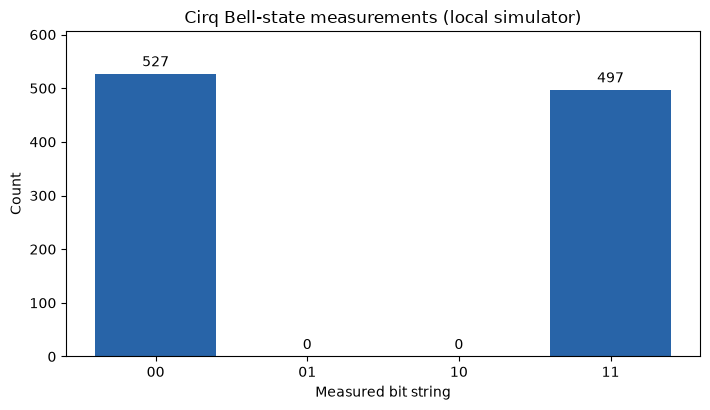

Saved D:\workshop\Codex\802-Quantum-Computing\submission\Task_1_Entanglement\task1_local_histogram.png


In [5]:
figure_path = Path("task1_local_histogram.png")
fig, ax = plt.subplots(figsize=(7.2, 4.2))
bars = ax.bar(basis_labels, [local_counts[label] for label in basis_labels], color="#2864A8")
ax.bar_label(bars, padding=3)
ax.set(title="Cirq Bell-state measurements (local simulator)", xlabel="Measured bit string", ylabel="Count")
ax.set_ylim(0, max(local_counts.values()) * 1.15)
fig.tight_layout()
fig.savefig(figure_path, dpi=180)
plt.show()
print(f"Saved {figure_path.resolve()}")


## 6. OpenQASM 2 and Quokka execution

The measured Cirq circuit is exported to OpenQASM 2 and sent to the course Quokka REST endpoint. The raw JSON response is retained unchanged alongside a normalized count table so the result is auditable.


## 7. Results and critical interpretation

This section compares local and Quokka probabilities, checks bit correlation, and distinguishes finite-shot sampling variation from circuit error.


## 8. Conclusion

The final conclusion will state whether the target Bell state was generated and whether device measurements provide the expected correlated evidence.


## References

[1] M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information*, 10th anniversary ed. Cambridge, UK: Cambridge University Press, 2010.  
[2] Google Quantum AI, "Cirq basics," 2026. [Online]. Available: https://quantumai.google/cirq/start/basics. [Accessed: 24-Jul-2026].  
[3] Quokka Quantum, "Quokka Puck technical specifications," 2026. [Online]. Available: https://www.quokkacomputing.com/product-page/quokka-puck. [Accessed: 24-Jul-2026].
